# Notebook 4 — Linear Regression

Linear Regression is a fundamental supervised learning algorithm used to model the relationship between a dependent variable and one or more independent variables. It predicts continuous values by fitting a straight line that best represents the data.

-It assumes that there is a linear relationship between the input and output

-Uses a best‑fit line to make predictions

-Commonly used in forecasting, trend analysis, and predictive modelling


### Load the Data

We'll use this data for every example below. It simulates a retail dataset:
each row is one order line, with a **Quantity** bought and a **UnitPrice**
per item.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
data = pd.read_csv("data.csv", encoding="latin1")
data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]
data = data.sample(200, random_state=1).reset_index(drop=True)
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,541838,82486,WOOD S/3 CABINET ANT WHITE FINISH,6,1/23/2011 10:43,7.95,12916.0,United Kingdom,47.70
1,581405,21894,POTTING SHED SEED ENVELOPES,2,12/8/2011 13:50,1.25,13521.0,United Kingdom,2.50
2,536557,22678,FRENCH BLUE METAL DOOR SIGN 3,3,12/1/2010 14:41,1.25,17841.0,United Kingdom,3.75
3,538071,22778,GLASS CLOCHE SMALL,1,12/9/2010 14:09,8.47,NaN,United Kingdom,8.47
4,539653,21479,WHITE SKULL HOT WATER BOTTLE,2,12/20/2010 16:50,3.75,13564.0,United Kingdom,7.50


## 1. What is Regression?

**Regression** is a family of machine learning techniques used to predict a
**continuous number** — something that can take on a wide, sliding range of
values (like a price, a temperature, or a distance), as opposed to a
category or label.

Example here: predict **Total Price** from **Quantity** ordered. As Quantity
goes up, we'd expect Total Price to go up too — regression tries to capture
that relationship mathematically.

In [2]:
print(data[["Quantity", "TotalPrice"]].head())

   Quantity  TotalPrice
0         6       47.70
1         2        2.50
2         3        3.75
3         1        8.47
4         2        7.50


## 2. Linear Regression

**Linear Regression** is the simplest and most common form of regression.
It assumes the relationship between the input(s) and the output can be
approximated by fitting a **straight line** (or a flat plane, with more
inputs) through the data — of the form `y = b1*x + b0`.

It won't perfectly capture curves or complex patterns, but it's a great
starting point: fast to train, easy to interpret, and a solid baseline
before trying more complex models.

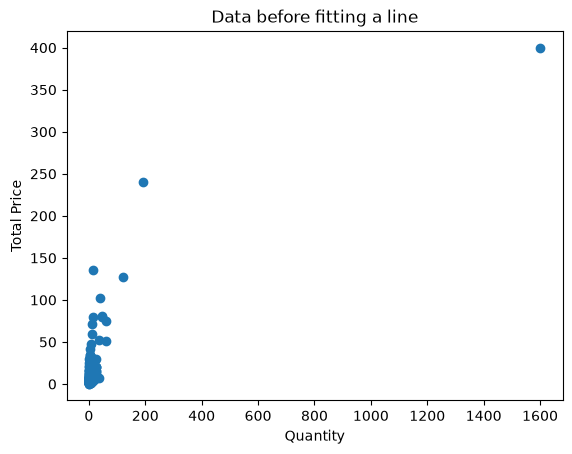

In [4]:
plt.scatter(data["Quantity"], data["TotalPrice"])
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.title("Data before fitting a line")
plt.show()

## 3. Independent Variable (x)

The **independent variable** (also called a **feature** or **predictor**)
is the input we already know and feed into the model. It's called
"independent" because its value doesn't depend on anything the model
computes — we simply observe it.

Here, `Quantity` is our independent variable: we already know how many
items were ordered.

In [3]:
x = data[["Quantity"]]
x.head()

,Quantity
0,6
1,2
2,3
3,1
4,2


## 4. Dependent Variable (y)

The **dependent variable** (also called the **target** or **label**) is the
output we're trying to predict. It's called "dependent" because its value
*depends on* the input(s) — that's the whole relationship we're modeling.

Here, `TotalPrice` is our dependent variable: its value depends on how many
items (`Quantity`) were bought.

In [4]:
y = data["TotalPrice"]
y.head()

0    47.70
1     2.50
2     3.75
3     8.47
4     7.50
Name: TotalPrice, dtype: float64

## 5. Simple Linear Regression

**Simple Linear Regression** uses exactly **one** input (`x`) to predict one
output (`y`). "Simple" here refers to the number of features, not how easy
the concept is — it just means we're only using a single predictor.

Now that `x` and `y` are defined above, we can safely fit the model.

In [6]:
model = LinearRegression()
model.fit(x, y)
print("Model trained!")
print(data[["Quantity", "TotalPrice"]].head())

Model trained!
   Quantity  TotalPrice
0         6       47.70
1         2        2.50
2         3        3.75
3         1        8.47
4         2        7.50


## 6. Multiple Linear Regression

**Multiple Linear Regression** uses **two or more** inputs to predict `y`.
Instead of fitting a single line, the model fits a flat plane (or
higher-dimensional surface) through the data — one weight per input feature.

Here we use both `Quantity` and `UnitPrice` to predict `TotalPrice`.

In [7]:
x_multi = data[["Quantity", "UnitPrice"]]
y_multi = data["TotalPrice"]
model2 = LinearRegression()
model2.fit(x_multi, y_multi)
print("Coefficients:", model2.coef_)
print("Intercept:", model2.intercept_)

Coefficients: [0.26831267 1.46574185]
Intercept: 8.601250022921171


## 7. Equation of a Line

Simple Linear Regression fits an equation of the form:

$$ y = b_1 x + b_0 $$

- `b1` is the **coefficient** (slope) — how steep the line is
- `b0` is the **intercept** — where the line crosses the y-axis
- `x` is the input value we plug in
- `y` is the predicted output

Once we know `b1` and `b0`, we can predict `y` for *any* value of `x`,
even ones the model has never seen before.

In [8]:
b1 = model.coef_[0]
b0 = model.intercept_
x_value = 10
y_value = b1 * x_value + b0
print("y =", y_value)

y = 15.67308893413778


## 8. Coefficient

The **coefficient** tells us how much `y` changes when `x` increases by
exactly 1 unit, holding everything else constant. It captures both the
**direction** and **strength** of the relationship:

- A positive coefficient → as `x` increases, `y` tends to increase too
- A negative coefficient → as `x` increases, `y` tends to decrease
- A larger magnitude → a stronger effect per unit of `x`

In [9]:
print("Coefficient:", model.coef_[0])

Coefficient: 0.26457117157277205


## 9. Intercept

The **intercept** is the predicted value of `y` when `x = 0` — it's where
the fitted line crosses the vertical axis. It doesn't always have a
meaningful real-world interpretation (ordering 0 items obviously means 0
total price!), but it's a necessary part of the equation for the line to
fit the data correctly.

In [10]:
print("Intercept:", model.intercept_)

Intercept: 13.02737721841006


## 10. Prediction

**Prediction** is the whole point of training a model: once it has learned
`b1` and `b0`, we feed in new `x` values and it outputs the corresponding
predicted `y` values. Here we predict `TotalPrice` for the real `Quantity`
values already in our dataset.

In [11]:
y_pred = model.predict(x)
y_pred[:5]

array([14.61480425, 13.55651956, 13.82109073, 13.29194839, 13.55651956])

## 11. Residuals

A **residual** is the difference between what actually happened and what
the model predicted:

$$ residual = actual - predicted $$

Residuals tell us how far off each individual prediction was. A good model
has residuals that are small and scattered randomly around zero, with no
obvious pattern. If residuals show a clear pattern (like a curve), it's a
sign that a straight line isn't a great fit for the data.

In [12]:
residual = y - y_pred
residual.head()

0    33.085196
1   -11.056520
2   -10.071091
3    -4.821948
4    -6.056520
Name: TotalPrice, dtype: float64

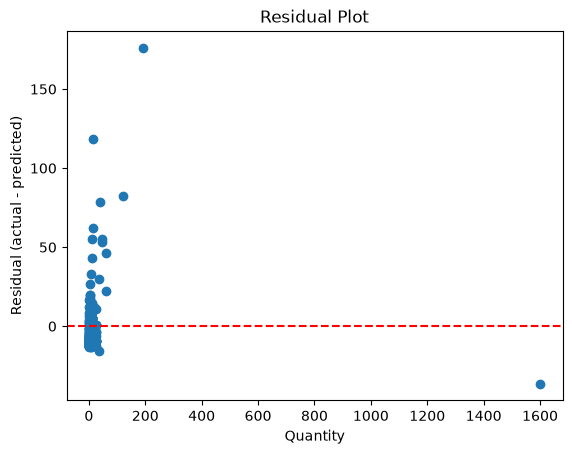

In [13]:
plt.scatter(x["Quantity"], residual)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Quantity")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual Plot")
plt.show()

## 12. Least Squares

**Least Squares** (specifically, Ordinary Least Squares) is the mathematical
method scikit-learn uses internally to find the *best-fitting* `b1` and
`b0`. "Best-fitting" here means the line that minimizes the **sum of squared
residuals** — squaring makes all errors positive and penalizes bigger
mistakes more heavily.

We can compute the same coefficient and intercept manually with a direct
formula, and it should match what `LinearRegression()` found.

In [14]:
x_arr = data["Quantity"].values
y_arr = data["TotalPrice"].values
b1_manual = np.sum((x_arr - x_arr.mean()) * (y_arr - y_arr.mean())) / np.sum((x_arr - x_arr.mean()) ** 2)
b0_manual = y_arr.mean() - b1_manual * x_arr.mean()
print("Coefficient (manual):", b1_manual)
print("Intercept (manual):  ", b0_manual)
print("Coefficient (sklearn):", model.coef_[0])
print("Intercept (sklearn):  ", model.intercept_)

Coefficient (manual): 0.2645711715727717
Intercept (manual):   13.027377218410066
Coefficient (sklearn): 0.26457117157277205
Intercept (sklearn):   13.02737721841006


## 13. Cost Function

A **cost function** (also called a **loss function**) measures how wrong the
model's predictions are overall, as a single number. For Linear Regression,
the most common cost function is **Mean Squared Error (MSE)**: the average
of all the squared residuals.

$$ J = \frac{1}{n}\sum (actual - predicted)^2 $$

The smaller the cost, the better the line fits the data. Training a model
is really just a search for the `b1` and `b0` that make this cost as small
as possible — which is exactly what Least Squares does directly, and what
Gradient Descent (next section) does step by step.

In [15]:
cost = np.mean((y - y_pred) ** 2)
print("Cost (MSE):", cost)

Cost (MSE): 472.92077518828705


## 14. Gradient Descent — Introduction

**Gradient Descent** is an alternative way to find `b0` and `b1`, used
especially when a direct formula (like Least Squares) is impractical, for
example with very large datasets or more complex models.

Instead of solving for the answer in one step, it starts with a guess
(often `b0 = 0`, `b1 = 0`) and repeatedly nudges both values in the
direction that reduces the cost function, a little at a time — like walking
downhill toward the lowest point of a valley.

The **learning rate** controls the size of each step. Too large and the
steps overshoot and the model can diverge; too small and it takes a very
long time to converge. Because our raw `Quantity` and `TotalPrice` values
aren't scaled to a small range, we need a *very* small learning rate here to
keep the steps stable.